In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma

In [6]:
a = np.sort(np.random.default_rng().choice(15,7,replace=False))
b = np.sort(np.random.default_rng().choice(25,7,replace=False)) + 4
#fma.statistics.hierarchicalBootstrap(b, [1,1,2,2,1,2,4] )
#A, B, C = fma.statistics.hierarchicalBootstrap(np.tile(b[:,None],(1,2)), [1,1,2,2,1,2,4], rng=1)
#A, B, C = fma.statistics.hierarchicalBootstrap(a, [0,0,0,0,1,1,1], b, [0,1,2,0,1,2,0], paired=True, rng=1)
#A, B, C = fma.statistics.hierarchicalBootstrap(np.array([a,a]).T, np.array([[0,0,0,0,1,1,1],[3,4,3,4,3,4,3]]).T, np.array([b,b]).T, np.array([[0,1,2,0,1,2,0],[2,3,4,2,3,4,4]]).T, paired=2)
A, B, C = fma.statistics.hierarchicalBootstrap(np.array([a,a]).T,np.array([[0,0,0,0,1,1,1],[3,4,3,4,3,4,3]]).T,np.array([a,a]).T,np.array([[0,1,2,0,1,2,0],[2,3,4,2,3,4,4]]).T,paired=2,rng=1)
B

array([[0.001998  , 0.001998  , 0.93706294],
       [0.001998  , 0.001998  , 0.93706294]])

In [7]:
#A1, B1, C1 = fma.statistics.hierarchicalBootstrapFAST(np.tile(b[:,None],(1,2)), [1,1,2,2,1,2,4], rng=1)
#A1, B1, C1 = fma.statistics.hierarchicalBootstrapFAST(a, [0,0,0,0,1,1,1], b, [0,1,2,0,1,2,0], paired=True, rng=1)
A1, B1, C1 = fma.statistics.hierarchicalBootstrap(np.array([a,a]).T, np.array([[0,0,0,0,1,1,1],[3,4,3,4,3,4,3]]).T, np.array([a,a]).T, np.array([[0,1,2,0,1,2,0],[2,3,4,2,3,4,4]]).T, paired=2, rng=1)
print(np.all(A==A1), np.all(B==B1), np.all(C==C1))

True True True


In [2]:
def make_dataset(subjects,trials,n_obs=10,mean=0.0,sd_subject=1.0,sd_trial=0.5,sd_obs=0.3,n_features=1,subject_effects=None,trial_effects=None,rng=None):
    """Generate one dataset with a 2-level hierarchy: subject -> trial -> observations.

    Model: value = mean + subject_effect + trial_effect + observation_noise

    subjects : sequence of subject ids present in this dataset (highest level).
    trials   : trial ids (lowest group level). Either
               - a sequence: the same trial ids for every subject, or
               - a dict {subject_id: sequence}: trial ids per subject.
               Trial ids only need to be unique within a subject.
    n_obs    : observations per trial. int for fixed, or (low, high) for a random integer
               drawn uniformly (inclusive) per trial, giving unbalanced groups.
    mean     : true grand mean, scalar or array (n_features,).
    sd_*     : std of subject effects, trial effects and observation noise. Set 0 to disable.
    subject_effects, trial_effects : optional dicts used as a cache of random effects.
               Pass the SAME dicts to two calls to make subjects (and trials) that share an id
               share their random effect, which induces correlation between X and Y (pairing).
               Keys: subject id, or (subject id, trial id).
    rng      : np.random.Generator, or seed.

    Returns
    -------
    data   : (n_samples, n_features)
    groups : (n_samples, 2), columns [trial, subject] (lowest to highest level)
    """
    rng = np.random.default_rng(rng)
    mean = np.broadcast_to(np.asarray(mean, dtype=float), (n_features,))
    subject_effects = {} if subject_effects is None else subject_effects
    trial_effects = {} if trial_effects is None else trial_effects

    data, groups = [], []
    for s in subjects:
        if s not in subject_effects:
            subject_effects[s] = rng.normal(0, sd_subject, n_features)
        s_trials = trials[s] if isinstance(trials, dict) else trials
        for t in s_trials:
            if (s, t) not in trial_effects:
                trial_effects[(s, t)] = rng.normal(0, sd_trial, n_features)
            n = n_obs if np.isscalar(n_obs) else rng.integers(n_obs[0], n_obs[1] + 1)
            values = (mean + subject_effects[s] + trial_effects[(s, t)]
                      + rng.normal(0, sd_obs, (n, n_features)))
            data.append(values)
            groups.append(np.tile([t, s], (n, 1)))
    return np.concatenate(data), np.concatenate(groups)

def make_pair(subjects_x,trials_x,subjects_y,trials_y,mean_x=0.0,mean_y=0.0,share_subject=True,share_trial=False,seed=None,**kwargs):
    """Generate X and Y. Ids that appear in both are shared in the random effects when
    share_subject / share_trial is True (use for paired designs). Other kwargs go to make_dataset."""
    rng = np.random.default_rng(seed)
    se = {} if share_subject else None
    te = {} if share_trial else None
    x, gx = make_dataset(subjects_x, trials_x, mean=mean_x, subject_effects=se, trial_effects=te, rng=rng, **kwargs)
    y, gy = make_dataset(subjects_y, trials_y, mean=mean_y, subject_effects=se, trial_effects=te, rng=rng, **kwargs)
    return x, gx, y, gy

In [11]:
# Paired design: same 12 subjects, 8 trials each, unbalanced observation counts, true difference 0.5
subj = range(12)
x, gx, y, gy = make_pair(subj, range(8), subj, range(8), mean_x=[0.,1.0], mean_y=[0.5,0.5], n_obs=(5,40), n_features=2, seed=0)
print("X:", x.shape, gx.shape, " Y:", y.shape, gy.shape)
# Correlation of subject means between conditions (should be high when subject effects are shared)
mx = np.array([x[gx[:, 1] == s].mean(0)[0] for s in subj])
my = np.array([y[gy[:, 1] == s].mean(0)[0] for s in subj])
print("corr of subject means X vs Y:", np.corrcoef(mx, my)[0, 1].round(2))

X: (2286, 2) (2286, 2)  Y: (2054, 2) (2054, 2)
corr of subject means X vs Y: 0.96


In [12]:
A, B, C = fma.statistics.hierarchicalBootstrap(x, gx, y, gy, paired=2, rng=1)

In [13]:
A1, B1, C1 = fma.statistics.hierarchicalBootstrapFAST(x, gx, y, gy, paired=2, rng=1)

True True True
[[0.43756244 0.18581419 0.001998  ]
 [0.001998   0.001998   0.001998  ]]


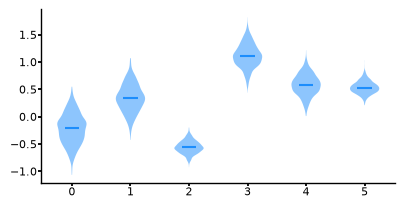

In [10]:
print(np.all(A==A1), np.all(B==B1), np.all(C==C1))
print(B)
fig, ax = fma.plotting.makeFigure(size=(10,5))
fma.plotting.boxPlot(A[:,0],x=range(3),mode='violin')
fma.plotting.boxPlot(A[:,1],x=range(3,6),mode='violin');

In [14]:
# Unpaired design: different subjects, partial trial-id overlap, null (equal means)
x, gx, y, gy = make_pair(range(0,10), range(8), range(100,115), range(3,12), mean_x=0.0, mean_y=0.0, share_subject=False, seed=1)
print("unpaired shared subject ids:", set(gx[:, 1]) & set(gy[:, 1]))

unpaired shared subject ids: set()


In [15]:
A, B, C = fma.statistics.hierarchicalBootstrap(x, gx, y, gy, paired=0, rng=10)

In [16]:
A1, B1, C1 = fma.statistics.hierarchicalBootstrapFAST(x, gx, y, gy, paired=0, rng=10)


True True True
[[0.10789211 0.53146853 0.10989011]]


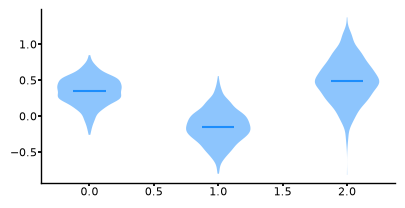

In [17]:
print(np.all(A==A1), np.all(B==B1), np.all(C==C1))
print(B)
fig, ax = fma.plotting.makeFigure(size=(10,5))
fma.plotting.boxPlot(A[:,0],x=range(3),mode='violin');